# Assignment


# Part 1: Introduction and set up

In this assignment, you will investigate the joint variability of three soil
properties. Soil properties vary naturally from sample to sample due to
differences in soil composition, depositional history, stress history, and
water content. These properties may also be statistically dependent.
Therefore, considering them jointly can provide information that is not
captured when each property is analysed separately.

The dataset **Soil Properties** contains laboratory soil-characterisation
data. In this exercise, we focus on three random variables:

- Unit weight, $\gamma$ ($\mathrm{kN/m^3}$)
- Water content, $w$ (%)
- Plasticity index, $PI$ (%)

In [1]:
import numpy as np
from scipy.stats import multivariate_normal
from scipy.stats import norm
import matplotlib.pyplot as plt
from statistics import mean, stdev

In [2]:
import os
from urllib.request import urlretrieve

def findfile(fname):
    if not os.path.isfile(fname):
        print(f'Downloading {fname}...')
        urlretrieve('https://github.com/TUDelft-MUDE/source-files/raw/main/file/'+fname, fname)

fname = 'Soil_Properties.csv'
findfile(fname)

In [3]:
# Load the three soil-property columns from the input file
raw = np.genfromtxt(fname, delimiter=',', names=True, dtype=float, encoding=None)

gamma = np.asarray(raw['gamma'], dtype=float)
w = np.asarray(raw['w'], dtype=float)
PI = np.asarray(raw['PI'], dtype=float)

data = np.column_stack((gamma, w, PI))

print(f'Number of complete observations = {len(data)}')
data

Number of complete observations = 127


array([[ 15.2       ,  74.4       ,  20.4       ],
       [ 14.9       ,  78.4       ,  34.2       ],
       [ 14.86250955,  44.42056396,  26.2       ],
       [ 14.99187335,  69.94963626,  33.5       ],
       [ 14.90279298,  70.70049394,  30.1       ],
       [ 17.5       ,  51.5       ,  16.5       ],
       [ 18.1       ,  39.4       ,  18.4       ],
       [ 16.1       ,  53.4       ,  18.4       ],
       [ 17.        ,  50.4       ,  26.9       ],
       [ 17.        ,  46.8       ,  29.3       ],
       [ 18.8       ,  32.9       ,  16.8       ],
       [ 16.8       ,  57.3       ,  27.6       ],
       [ 15.4069588 ,  66.72077922,  31.7       ],
       [ 15.8       ,  68.1       ,  30.2       ],
       [ 15.99356031,  64.40009855,  26.7       ],
       [ 15.8       ,  53.4       ,  22.7       ],
       [ 14.59817549,  69.5545766 ,  36.4       ],
       [ 14.2       ,  88.6       ,  51.3       ],
       [ 17.7       ,  32.2       ,  26.        ],
       [ 14.9       ,  69.1    

## Part 2: Data exploration

> **Task 2.1:**
>
>Plot the data. Examine the histogram of each soil property and the scatter plots for each pair of properties.
>
>What can you conclude about:
>- the shape and variability of the marginal distributions; and
>- the direction and approximate strength of dependence between the soil properties?


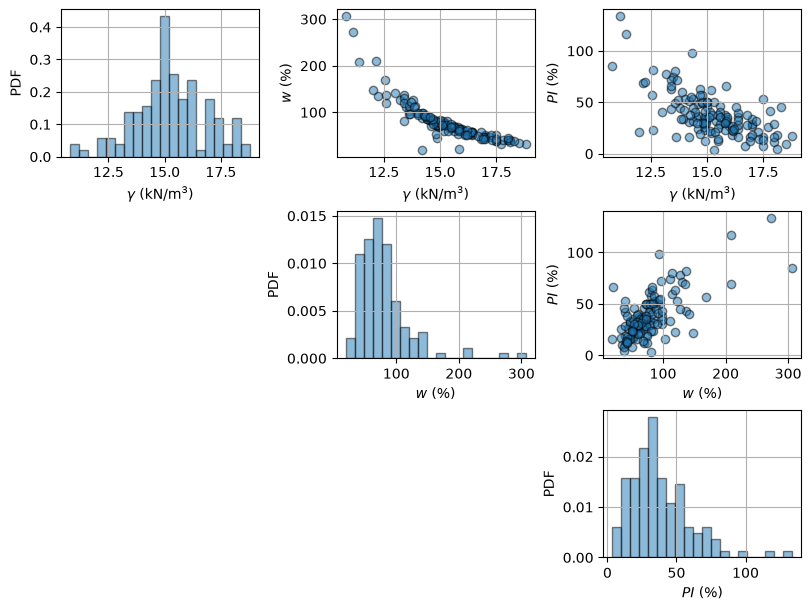

In [4]:
variable_names = [
    r'$\gamma$ (kN/m$^3$)',
    r'$w$ (%)',
    r'$PI$ (%)'
]

fig, axs = plt.subplots(3, 3, figsize=(8, 6), layout='constrained')

for i in range(data.shape[1]):
    for j in range(data.shape[1]):
        if i == j:
            axs[i, j].grid()
            axs[i, j].hist(
                data[:, i],
                bins=20,
                density=True,
                alpha=0.5,
                edgecolor='black'
            )
            axs[i, j].set_xlabel(variable_names[i])
            axs[i, j].set_ylabel('PDF')

        elif i < j:
            axs[i, j].grid()
            axs[i, j].scatter(
                data[:, i],
                data[:, j],
                alpha=0.5,
                edgecolor='black'
            )

            axs[i, j].set_xlabel(variable_names[i])
            axs[i, j].set_ylabel(variable_names[j])

        else:
            axs[i, j].axis('off')
plt.show()

> **Task 2.2:**
>
>Quantify the strength of the linear dependence between each pair using Pearson's correlation coefficient. What can you conclude?


In [5]:
def calculate_covariance(X1, X2):
    mean_x1 = mean(X1)
    mean_x2 = mean(X2)

    # Calculate deviations from the mean
    diff_x1 = X1 - mean_x1
    diff_x2 = X2 - mean_x2

    # Multiply paired deviations
    product = diff_x1 * diff_x2

    # Sample covariance
    covariance = sum(product) / (len(X1) - 1)

    return covariance


def pearson_correlation(X1, X2):
    covariance = calculate_covariance(X1, X2)

    std_x1 = np.std(X1, ddof=1)
    std_x2 = np.std(X2, ddof=1)

    correl_coeff = covariance / (std_x1 * std_x2)

    return correl_coeff


print("Pearson's correlation coefficient between γ and w is",
      np.round(pearson_correlation(data[:,0], data[:,1]), 3))

print("Pearson's correlation coefficient between γ and PI is",
      np.round(pearson_correlation(data[:,0], data[:,2]), 3))

print("Pearson's correlation coefficient between w and PI is",
      np.round(pearson_correlation(data[:,1], data[:,2]), 3))


Pearson's correlation coefficient between γ and w is -0.849
Pearson's correlation coefficient between γ and PI is -0.642
Pearson's correlation coefficient between w and PI is 0.684


## Part 3: Multivariate Gaussian distribution

> **Task 3.1:**
>
>Model the joint distribution of $\gamma$, $w$ and $PI$ using a multivariate Gaussian distribution. Follow the steps:
>- Define the vector of means.
>- Define the covariance matrix.
>- Draw 500 samples from the fitted trivariate Gaussian distribution and compare them with the observations.
>
>Do you see differences between the observations and the Gaussian samples? Compare both the univariate marginal distributions and the bivariate scatter plots.


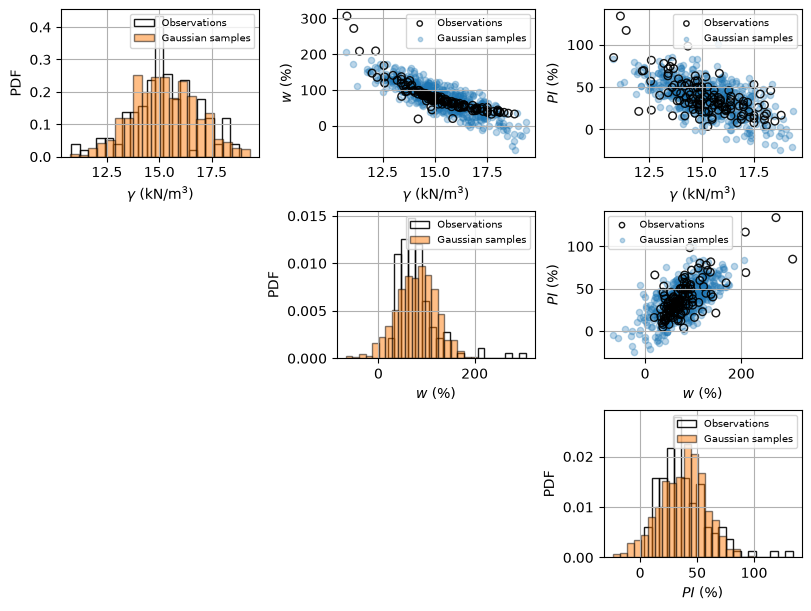

In [6]:
# ---------------------------------------------------------
# Define the vector of means
# ---------------------------------------------------------

mu1 = mean(data[:, 0])
mu2 = mean(data[:, 1])
mu3 = mean(data[:, 2])

mu = np.array([mu1, mu2, mu3])


# ---------------------------------------------------------
# Define the covariance matrix
# ---------------------------------------------------------

s1 = np.std(data[:, 0], ddof=1)
s2 = np.std(data[:, 1], ddof=1)
s3 = np.std(data[:, 2], ddof=1)

covariance_12 = calculate_covariance(data[:, 0], data[:, 1])
covariance_13 = calculate_covariance(data[:, 0], data[:, 2])
covariance_23 = calculate_covariance(data[:, 1], data[:, 2])

sigma = np.array([
    [s1**2, covariance_12, covariance_13],
    [covariance_12, s2**2, covariance_23],
    [covariance_13, covariance_23, s3**2]
])


# ---------------------------------------------------------
# Draw 500 samples from the fitted trivariate Gaussian
# ---------------------------------------------------------

samples = multivariate_normal.rvs(mean=mu, cov=sigma, size=500)


# ---------------------------------------------------------
# Compare samples with observations
# ---------------------------------------------------------

fig, axs = plt.subplots(
    3, 3,
    figsize=(8, 6),
    layout='constrained'
)

for i in range(data.shape[1]):
    for j in range(data.shape[1]):

        # Marginal distributions
        if i == j:

            axs[i, j].grid()

            axs[i, j].hist(
                data[:, i],
                bins=20,
                density=True,
                alpha=0.9,
                edgecolor='black',
                facecolor='none',
                label='Observations'
            )

            axs[i, j].hist(
                samples[:, i],
                bins=20,
                density=True,
                alpha=0.5,
                edgecolor='black',
                label='Gaussian samples'
            )

            axs[i, j].set_xlabel(variable_names[i])
            axs[i, j].set_ylabel('PDF')

            axs[i, j].legend(fontsize=7)


        # Scatter plots
        elif i < j:

            axs[i, j].grid()

            # Gaussian samples first
            axs[i, j].scatter(
                samples[:, i],
                samples[:, j],
                alpha=0.30,
                s=20,
                label='Gaussian samples'
            )

            # Observations on top
            axs[i, j].scatter(
                data[:, i],
                data[:, j],
                alpha=0.9,
                s=30,
                edgecolor='black',
                facecolor='none',
                label='Observations'
            )

            axs[i, j].set_xlabel(variable_names[i])
            axs[i, j].set_ylabel(variable_names[j])

            # Put observations first in legend
            handles, labels = axs[i, j].get_legend_handles_labels()

            axs[i, j].legend(
                [handles[1], handles[0]],
                [labels[1], labels[0]],
                fontsize=7,
                markerscale=0.7
            )

        else:

            axs[i, j].axis('off')

plt.show()

> **Task 3.2:**
>
>Suppose we are interested in soil with the following properties:
>
>- unit weight: $\gamma < 16\ \mathrm{kN/m^3}$
>- water content: $w > 80\%$
>- plasticity index: $PI > 30\%$
>
>Using samples generated from the fitted multivariate Gaussian distribution, estimate the probability that **all three conditions are satisfied at the same time**.
>
>Repeat the calculation using different numbers of samples,
>
>$$
>N = 100,\quad 1{,}000,\quad 10{,}000,\quad 100{,}000,\quad 1{,}000{,}000.
>$$
>
>How does the estimated probability behave as the number of samples increases? Comment on the stability of the estimate.
>
>**Hint:** For each generated sample, check whether all three conditions are satisfied. The probability can be estimated as the proportion of generated samples that satisfy all three conditions.


In [7]:
# Investigate the effect of sample size
sample_sizes = [100, 1000, 10000, 100000, 1000000]

for N in sample_sizes:

    # Draw samples from the fitted multivariate Gaussian distribution
    samples = multivariate_normal.rvs(mean=mu, cov=sigma, size=N)

    # Check the three screening criteria simultaneously
    condition = ((samples[:, 0] < 16.0) &
                 (samples[:, 1] > 80.0) &
                 (samples[:, 2] > 30.0)
    )

    # Estimate the probability as the proportion satisfying all three conditions
    prob_meeting_condition = np.mean(condition)

    print(f'N = {N:7d}: estimated probability = {prob_meeting_condition:.4f}')

N =     100: estimated probability = 0.4000
N =    1000: estimated probability = 0.3990
N =   10000: estimated probability = 0.4062
N =  100000: estimated probability = 0.4098
N = 1000000: estimated probability = 0.4100


## Part 4: Conditioning the multivariate Gaussian distribution


> **Task 4.1:**
>
>Suppose a laboratory measurement gives a water content of
>
>$$
>w = 120\%
>$$
>
>which is above the sample mean. What does this observation imply for the joint distribution of unit weight $\gamma$ and plasticity index $PI$?
>
>1. Compute the conditional distribution of $\gamma$ and $PI$ given $w = 120\%$.
>
>2. Compute the conditional probability
>
>$$
>P\left(
>\gamma < 16\ \mathrm{kN/m^3},
>\quad
>PI > 30\%
>\mid
>w = 120\%
>\right).
>$$


In [59]:
# Conditional distribution of X = [γ, PI] given Y = w = 120%

a = 120.0

# Partition the mean vector for X = [gamma, PI] and Y = w
mu_X = np.array([
    mu[0],      # mean of gamma
    mu[2]       # mean of PI
])
mu_Y = mu[1]    # mean of w

# Partition the covariance matrix
Sigma_XX = np.array([
    [sigma[0, 0], sigma[0, 2]],
    [sigma[2, 0], sigma[2, 2]]
])

Sigma_XY = np.array([
    [sigma[0, 1]],
    [sigma[2, 1]]
])

Sigma_YY = sigma[1, 1]

Sigma_YX = Sigma_XY.T

# ---------------------------------------------------------
# Conditional Gaussian equations
#
# mu_X|Y = mu_X + Sigma_XY * Sigma_YY^(-1) * (a - mu_Y)
#
# Sigma_X|Y = Sigma_XX
#             - Sigma_XY * Sigma_YY^(-1) * Sigma_YX
# ---------------------------------------------------------

# Conditional mean vector
cond_mu_vector = (mu_X.reshape(-1, 1) + Sigma_XY * Sigma_YY**(-1) * (a - mu_Y)).flatten()

# Conditional covariance matrix
cond_sigma_matrix = (Sigma_XX - Sigma_XY * Sigma_YY**(-1) * Sigma_YX)

# Conditional standard deviations
cond_std = np.sqrt(np.diag(cond_sigma_matrix))

print('Conditional mean [γ, PI] =')
print(np.round(cond_mu_vector, 3))

print('\nConditional covariance matrix =')
print(np.round(cond_sigma_matrix, 3))

print('\nConditional standard deviations [γ, PI] =')
print(np.round(cond_std, 3))

# ---------------------------------------------------------
# Generate samples from the conditional Gaussian distribution
# ---------------------------------------------------------

N = 100000
cond_samples = multivariate_normal.rvs(mean=cond_mu_vector, cov=cond_sigma_matrix, size=N)

# ---------------------------------------------------------
# Estimate P(gamma < 16, PI > 30 | w = 120%)
# ---------------------------------------------------------

condition = ((cond_samples[:, 0] < 16.0) &
             (cond_samples[:, 1] > 30.0)
)
cond_prob = np.mean(condition)

print(
    f'\nConditional probability '
    f'P(γ < 16, PI > 30 | w = 120%) = {cond_prob:.4f}'
)


Conditional mean [γ, PI] =
[13.922 52.47 ]

Conditional covariance matrix =
[[  0.715  -2.131]
 [ -2.131 251.538]]

Conditional standard deviations [γ, PI] =
[ 0.846 15.86 ]

Conditional probability P(γ < 16, PI > 30 | w = 120%) = 0.9163


> **Task 4.2:**
>
>Using the results from the previous task, compare the **conditional** and **unconditional** distributions of $\gamma$ and $PI$.
>
>1. Plot the conditional and unconditional **marginal distributions** of $\gamma$ and $PI$.
>
>2. Plot the conditional and unconditional **joint probability density contours** of $\gamma$ and $PI$.
>
>3. Compare the two cases and explain:
>   - how the mean values change after conditioning on $w = 120\%$;
>   - how the uncertainty changes;
>   - how these changes are related to the correlations of $\gamma$ and $PI$ with $w$.


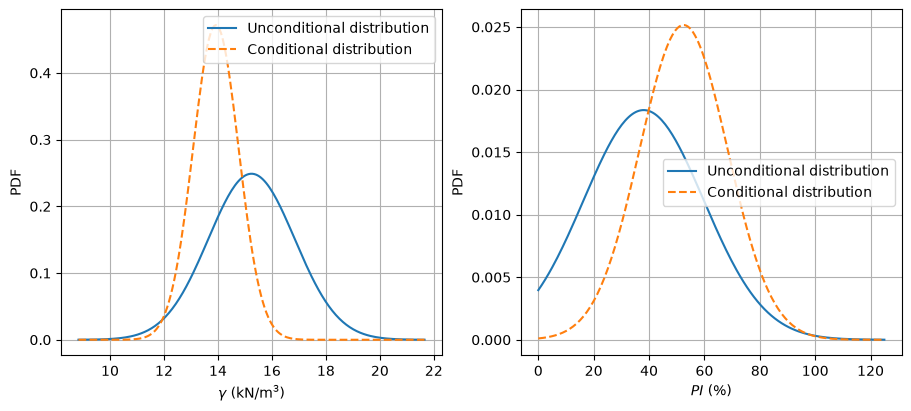

In [60]:
# Compare conditional and unconditional marginals of γ and PI

values_gamma = np.linspace(
    max(0, mu[0] - 4*np.sqrt(sigma[0,0])),
    mu[0] + 4*np.sqrt(sigma[0,0]),
    200
)

uncond_γ_pdf = norm.pdf(values_gamma, loc=mu[0], scale=np.sqrt(sigma[0,0]))

cond_γ_pdf = norm.pdf(values_gamma, loc=cond_mu_vector[0], scale=cond_std[0])


values_PI = np.linspace(
    max(0, mu[2] - 4*np.sqrt(sigma[2,2])),
    mu[2] + 4*np.sqrt(sigma[2,2]),
    200
)

uncond_PI_pdf = norm.pdf(values_PI, loc=mu[2], scale=np.sqrt(sigma[2,2]))

cond_PI_pdf = norm.pdf(values_PI, loc=cond_mu_vector[1], scale=cond_std[1])


# Plot marginal distributions
fig, ax = plt.subplots(1, 2, figsize=(9, 4), layout='constrained')

# γ
ax[0].plot(
    values_gamma,
    uncond_γ_pdf,
    label='Unconditional distribution'
)

ax[0].plot(
    values_gamma,
    cond_γ_pdf,
    '--',
    label='Conditional distribution'
)

ax[0].grid()
ax[0].set_xlabel(r'$\gamma$ (kN/m$^3$)')
ax[0].set_ylabel('PDF')
ax[0].legend()


# PI
ax[1].plot(
    values_PI,
    uncond_PI_pdf,
    label='Unconditional distribution'
)

ax[1].plot(
    values_PI,
    cond_PI_pdf,
    '--',
    label='Conditional distribution'
)

ax[1].grid()
ax[1].set_xlabel(r'$PI$ (%)')
ax[1].set_ylabel('PDF')
ax[1].legend()

plt.show()

[5.43604976e-14 6.40713697e-14 7.54050646e-14 ... 1.27427968e-24
 1.02702602e-24 8.26521316e-25]


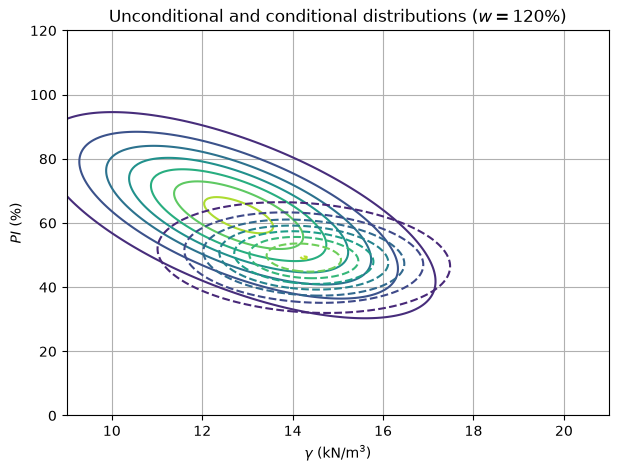

In [68]:
# Compare joint conditional and unconditional distributions of γ and PI

# ---------------------------------------------------------
# 1. Create values for γ and PI
# ---------------------------------------------------------

values_gamma = np.linspace(9, 21, 200)
values_PI = np.linspace(0, 120, 200)

# Create a two-dimensional grid of γ and PI
G, I = np.meshgrid(values_gamma, values_PI)


# ---------------------------------------------------------
# 2. Define the unconditional distribution of [γ, PI]
# ---------------------------------------------------------

uncond_mu = [
    mu[0],      # mean of γ
    mu[2]       # mean of PI
]

uncond_cov = np.array([
    [sigma[0, 0], sigma[0, 2]],
    [sigma[2, 0], sigma[2, 2]]
])


# ---------------------------------------------------------
# 3. Calculate the joint PDFs
# ---------------------------------------------------------

# Create pairs of [γ, PI] values
X = np.concatenate((G.T.reshape(-1, 1), I.T.reshape(-1, 1)), axis=1)
# Hint: use np.concatenate on G.T and I.T, then stack the two 1D arrays as columns.

# Unconditional joint PDF
Z_uncond = multivariate_normal.pdf(X, mean=uncond_mu, cov=uncond_cov)

# Conditional joint PDF given w = 120%
Z_cond = multivariate_normal.pdf(X, mean=cond_mu_vector, cov=cond_sigma_matrix)

print(Z_cond)

# Convert the PDF values back to the two-dimensional grid
Z_uncond = Z_uncond.reshape(G.shape)
Z_cond = Z_cond.reshape(G.shape)


# ---------------------------------------------------------
# 4. Plot the contours
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(7, 5))

ax.contour(
    G, I, Z_uncond,
    levels=8,
    linestyles='-'
)

ax.contour(
    G, I, Z_cond,
    levels=8,
    linestyles='--'
)

ax.grid()

ax.set_xlabel(r'$\gamma$ (kN/m$^3$)')
ax.set_ylabel(r'$PI$ (%)')

ax.set_title(
    r'Unconditional and conditional distributions ($w=120\%$)'
)

plt.show()

> By Zheng Guan, Delft University of Technology. CC BY 4.0, more info [on the Credits page of Workbook](https://mude.citg.tudelft.nl/workbook-2026/credits.html).
